In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
RAW_DIR = "../data/raw"

In [3]:
sales = pd.read_csv(f"{RAW_DIR}/sales_train_validation.csv")
calendar = pd.read_csv(f"{RAW_DIR}/calendar.csv")
prices = pd.read_csv(f"{RAW_DIR}/sell_prices.csv")

print("sales:", sales.shape)
print("calendar:", calendar.shape)
print("prices:", prices.shape)

sales: (30490, 1919)
calendar: (1969, 14)
prices: (6841121, 4)


In [4]:
sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,d_11,d_12,d_13,d_14,d_15,d_16,d_17,d_18,d_19,...,d_1889,d_1890,d_1891,d_1892,d_1893,d_1894,d_1895,d_1896,d_1897,d_1898,d_1899,d_1900,d_1901,d_1902,d_1903,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,4,2,3,0,1,2,0,0,0,1,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0,0,0,0,1,2,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,3,1,2,1,3,1,0,2,5,4,2,0,3,0,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,4,0,1,4,0,1,0,1,0,1,1,2,0,1,1,2,1,1,0,1,1,2,2,2,4


In [5]:
calendar.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [6]:
prices.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [7]:
print("stores:", sales["store_id"].nunique())
print("states:", sales["state_id"].nunique())
print("categories:", sales["cat_id"].nunique())
print("departments:", sales["dept_id"].unique())
print("unique items:", sales["item_id"].nunique())

stores: 10
states: 3
categories: 3
departments: <ArrowStringArray>
[  'HOBBIES_1',   'HOBBIES_2', 'HOUSEHOLD_1', 'HOUSEHOLD_2',     'FOODS_1',
     'FOODS_2',     'FOODS_3']
Length: 7, dtype: str
unique items: 3049


In [8]:
sales["cat_id"].value_counts()

cat_id
FOODS        14370
HOUSEHOLD    10470
HOBBIES       5650
Name: count, dtype: int64

In [9]:
print(sales.isnull().sum().sum())
print(calendar.isnull().sum())
print(prices.isnull().sum())

0
date               0
wm_yr_wk           0
weekday            0
wday               0
month              0
year               0
d                  0
event_name_1    1807
event_type_1    1807
event_name_2    1964
event_type_2    1964
snap_CA            0
snap_TX            0
snap_WI            0
dtype: int64
store_id      0
item_id       0
wm_yr_wk      0
sell_price    0
dtype: int64


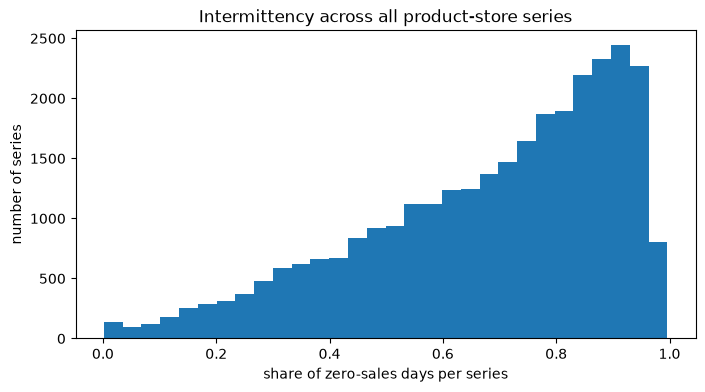

median zero-sales share: 0.7354939884997387


In [10]:
day_cols = [c for c in sales.columns if c.startswith("d_")]
zero_share = (sales[day_cols] == 0).sum(axis=1) / len(day_cols)

plt.figure(figsize=(8, 4))
plt.hist(zero_share, bins=30)
plt.xlabel("share of zero-sales days per series")
plt.ylabel("number of series")
plt.title("Intermittency across all product-store series")
plt.show()

print("median zero-sales share:", zero_share.median())

In [11]:
id_cols = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]
sample_ids = sales.sample(5, random_state=42)["id"]
sample = sales[sales["id"].isin(sample_ids)]

long_sample = sample.melt(id_vars=id_cols, value_vars=day_cols, var_name="d", value_name="sales")
long_sample = long_sample.merge(calendar[["d", "date"]], on="d")
long_sample["date"] = pd.to_datetime(long_sample["date"])
long_sample.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date
0,FOODS_3_180_CA_1_validation,FOODS_3_180,FOODS_3,FOODS,CA_1,CA,d_1,0,2011-01-29
1,FOODS_1_097_CA_2_validation,FOODS_1_097,FOODS_1,FOODS,CA_2,CA,d_1,0,2011-01-29
2,HOUSEHOLD_2_383_CA_3_validation,HOUSEHOLD_2_383,HOUSEHOLD_2,HOUSEHOLD,CA_3,CA,d_1,2,2011-01-29
3,FOODS_3_409_CA_3_validation,FOODS_3_409,FOODS_3,FOODS,CA_3,CA,d_1,0,2011-01-29
4,HOBBIES_1_272_TX_2_validation,HOBBIES_1_272,HOBBIES_1,HOBBIES,TX_2,TX,d_1,0,2011-01-29


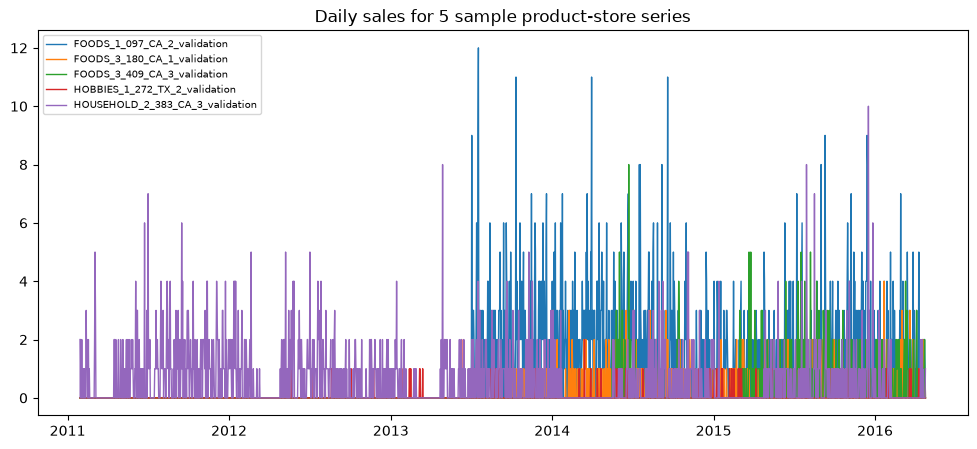

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
for series_id, group in long_sample.groupby("id"):
    ax.plot(group["date"], group["sales"], label=series_id, linewidth=1)
ax.legend(fontsize=7)
ax.set_title("Daily sales for 5 sample product-store series")
plt.show()

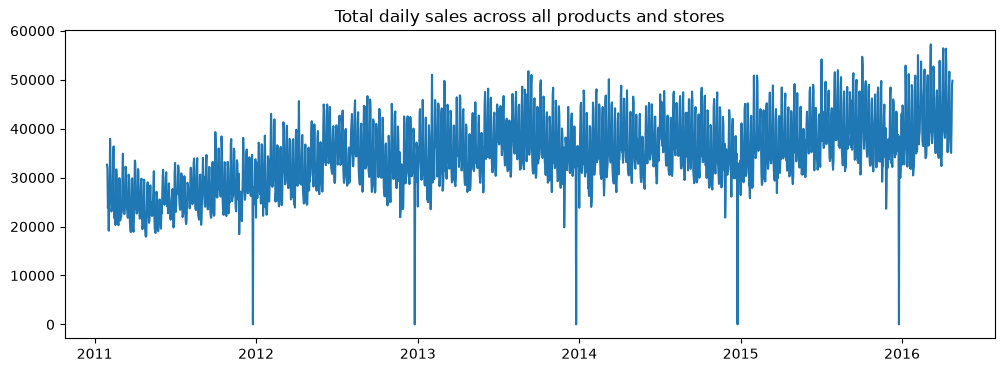

In [14]:
total_daily = sales[day_cols].sum(axis=0)
total_daily.index = calendar.set_index("d").loc[total_daily.index, "date"]
total_daily.index = pd.to_datetime(total_daily.index)

plt.figure(figsize=(12, 4))
plt.plot(total_daily.index, total_daily.values)
plt.title("Total daily sales across all products and stores")
plt.show()

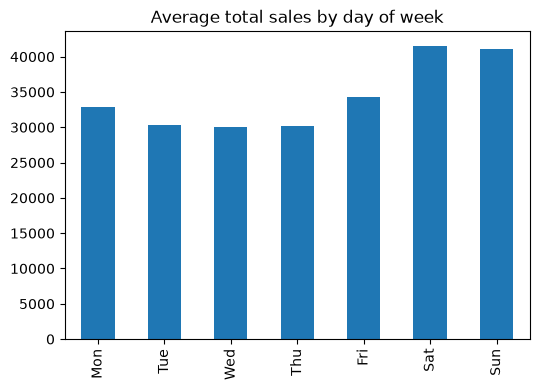

In [15]:
weekly = total_daily.groupby(total_daily.index.dayofweek).mean()
weekly.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

plt.figure(figsize=(6, 4))
weekly.plot(kind="bar")
plt.title("Average total sales by day of week")
plt.show()

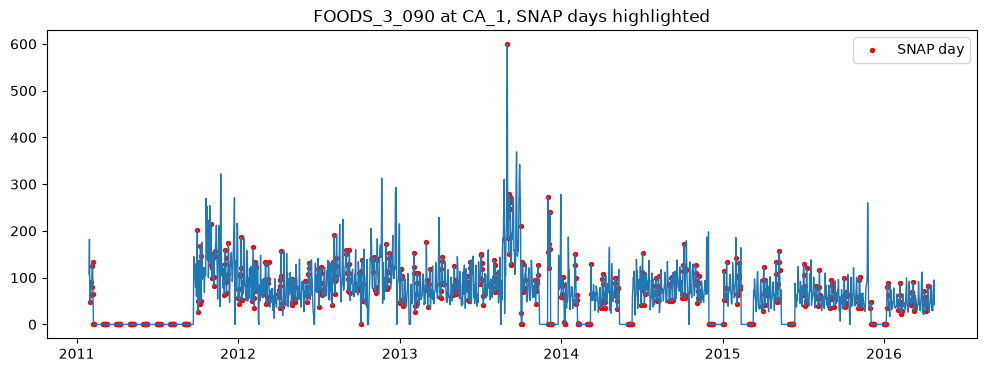

In [16]:
sample_item = "FOODS_3_090"
sample_store = "CA_1"

series = sales[(sales["item_id"] == sample_item) & (sales["store_id"] == sample_store)]
if len(series) > 0:
    series_long = series.melt(id_vars=id_cols, value_vars=day_cols, var_name="d", value_name="sales")
    series_long = series_long.merge(calendar[["d", "date", "snap_CA"]], on="d")
    series_long["date"] = pd.to_datetime(series_long["date"])

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(series_long["date"], series_long["sales"], linewidth=1)
    snap_days = series_long[series_long["snap_CA"] == 1]
    ax.scatter(snap_days["date"], snap_days["sales"], color="red", s=8, label="SNAP day")
    ax.legend()
    ax.set_title(f"{sample_item} at {sample_store}, SNAP days highlighted")
    plt.show()
else:
    print("sample item/store combination not found, pick another id from sales['item_id']")